# Importing Libraries

In [26]:

import numpy as np
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
data = pd.read_csv('data/Training Dataset.csv')
print(data)

      Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0         NaN           

In [28]:
print(data.info)

<bound method DataFrame.info of       Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849          

In [29]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [30]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

# Removing null values
### Gender = object = fill (mode)

### Married = object = fill(mode)

### Dependents = object = fill(mode)

### Self_Employed = object = fill(mode)

### LoanAmount = int = fill(median)

### Loan_Amount_Term = int = fill (median)

### Credit_History = int = fill(median

In [31]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].median())
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].median())
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].median())
print(data)

      Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0       128.0           

In [32]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

# EDA

In [33]:
num = data.select_dtypes(['int64','float64'])
correlation_matrix = num.corr()
correlation_matrix


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.565181,-0.046531,-0.018615
CoapplicantIncome,-0.116605,1.000000,0.189218,-0.059383,0.011134
LoanAmount,0.565181,0.189218,1.000000,0.036960,-0.000607
Loan_Amount_Term,-0.046531,-0.059383,0.036960,1.000000,-0.004705
Credit_History,-0.018615,0.011134,-0.000607,-0.004705,1.000000


<Axes: >

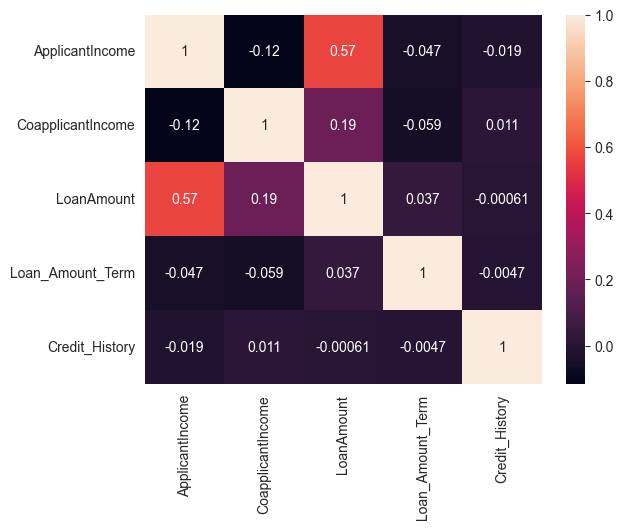

In [10]:
sns.heatmap(correlation_matrix , annot = True  )

## Categorical data


In [11]:
for i in data.columns:
  x = data[i].value_counts()
  print(x)
  print()

Loan_ID
LP001002    1
LP002328    1
LP002305    1
LP002308    1
LP002314    1
           ..
LP001692    1
LP001693    1
LP001698    1
LP001699    1
LP002990    1
Name: count, Length: 614, dtype: int64

Gender
Male      502
Female    112
Name: count, dtype: int64

Married
Yes    401
No     213
Name: count, dtype: int64

Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

Self_Employed
No     532
Yes     82
Name: count, dtype: int64

ApplicantIncome
2500    9
4583    6
6000    6
2600    6
3333    5
       ..
3244    1
4408    1
3917    1
3992    1
7583    1
Name: count, Length: 505, dtype: int64

CoapplicantIncome
0.0       273
2500.0      5
2083.0      5
1666.0      5
2250.0      3
         ... 
2791.0      1
1010.0      1
1695.0      1
2598.0      1
240.0       1
Name: count, Length: 287, dtype: int64

LoanAmount
128.0    33
120.0    20
110.0    17
100.0    15
160.0    12
         ..


In [12]:
cat = data[['Gender' ,'Married' ,'Dependents' , 'Education' ,'Self_Employed','Credit_History' ,'Property_Area' ,'Loan_Status']]
cat

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,1.0,Urban,Y
4,Male,No,0,Graduate,No,1.0,Urban,Y
...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,1.0,Urban,Y


In [13]:
for i in cat.columns:
  x = cat[i].value_counts()
  print(x)
  print()

Gender
Male      502
Female    112
Name: count, dtype: int64

Married
Yes    401
No     213
Name: count, dtype: int64

Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

Self_Employed
No     532
Yes     82
Name: count, dtype: int64

Credit_History
1.0    525
0.0     89
Name: count, dtype: int64

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

Loan_Status
Y    422
N    192
Name: count, dtype: int64



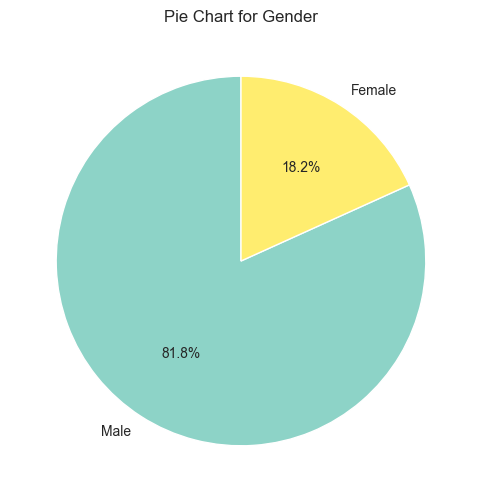

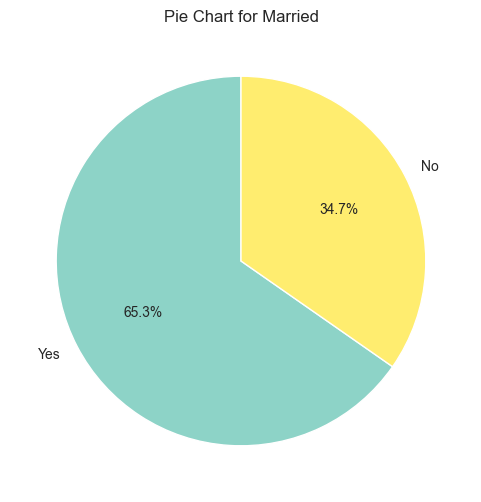

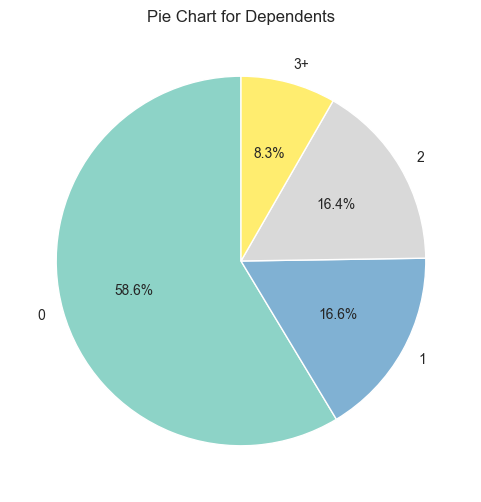

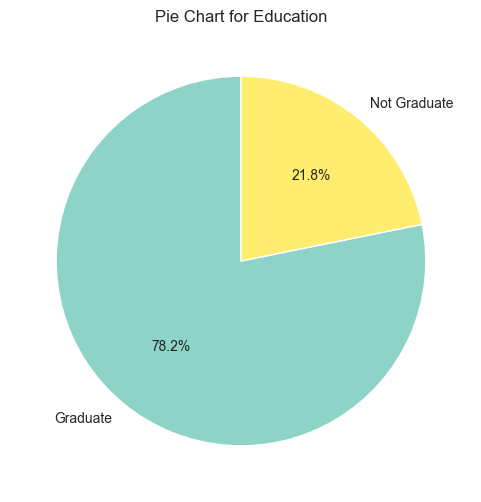

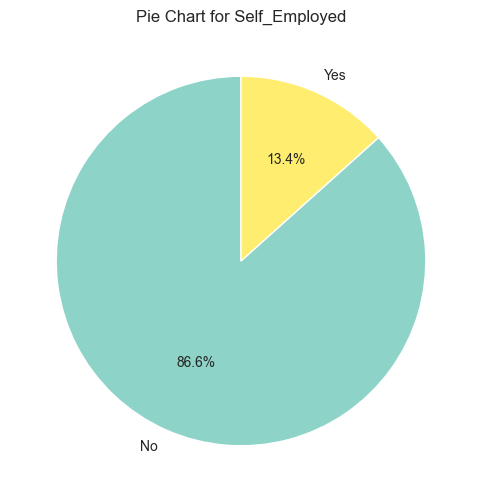

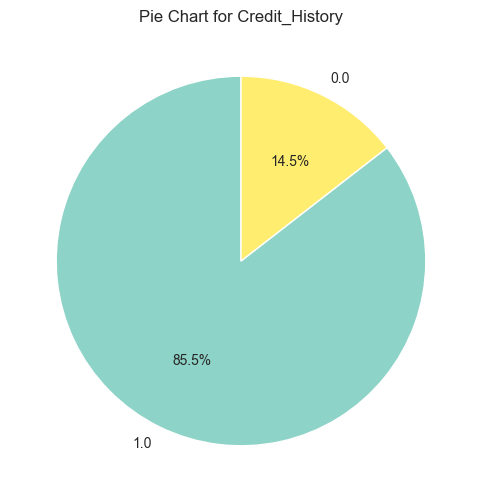

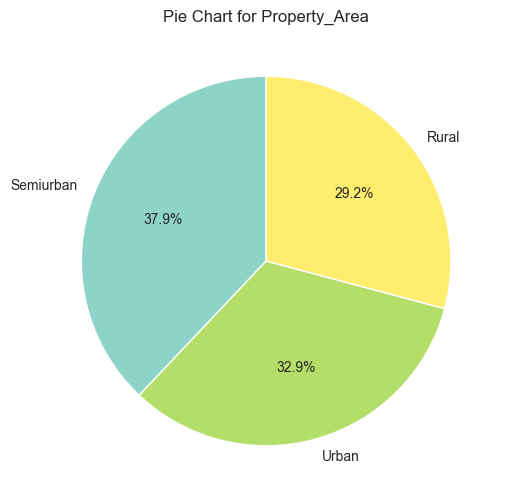

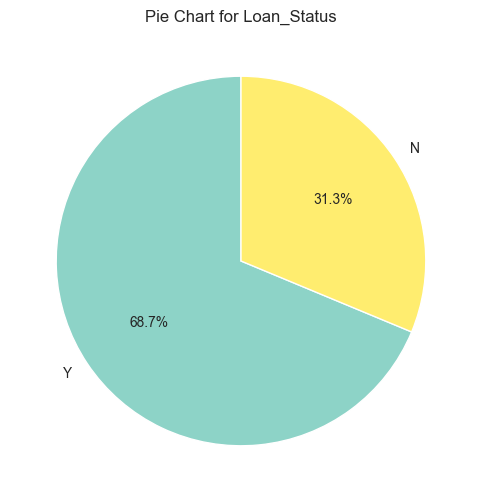

In [14]:
for col in cat.columns:
    plt.figure(figsize=(6, 6))
    data[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap="Set3")
    plt.title(f"Pie Chart for {col}")
    plt.ylabel('')
    plt.show()

<Axes: xlabel='Gender'>

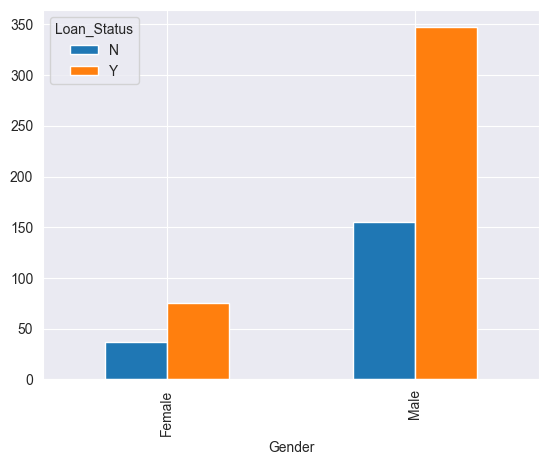

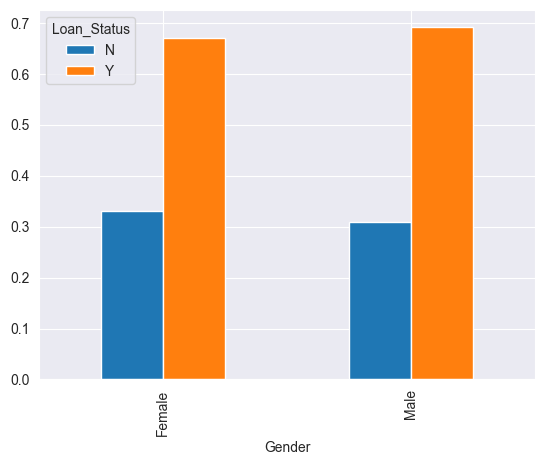

In [17]:
Gender = pd.crosstab(data['Gender'] , data['Loan_Status'])  # before normalize
Gender.plot(kind='bar')\


Gender = pd.crosstab(data['Gender'] , data['Loan_Status'] ,normalize='index') #after normalize
Gender.plot(kind='bar')

We analyze the results of the graphs:
add Codeadd Markdown
:1-Comparing Married Applicants with Loan Status:
Comparing the loan status withmarried applicants, who make up 64%of the total

loan applicants

and unmarried applicants, who make up 35% , we observe that married

applicants are more likely to apply for financial loans than single applicants.

Thus, married applicants receive loans more often than single ones.

The rejection rate for married applicants is less than 50%, while for single applicants, the rejection rate is greater than 50%.

2-Comparing Loan Status with Dependent Groups:
"First Case:Applicants with No Dependents"

Applicants with no dependents make up 59% of the dependent category.

They represent the largest proportion of loan applicants among all dependency

cases, and most of them receive loan approval.

The rejection rate for this group is less than 50%.

"Second Case: Applicants with One Dependent"

Applicants in this case constitute 16.4% of the dependent category.

The approval rate is higher than the rejection rate by less than 50%.

However, the rejection rate for this group is over 50%.

"Third Case: Applicants with Two Dependents"

Applicants in the third case make up 16% of the dependent category.

The approval rate in this group is significantly higher than the rejection rate.

The rejection rate is approximately 25%.

"Fourth Case: Applicants with Three Dependents"

Applicants in the fourth case represent 7.8% of the dependent category.

The approval rate is higher than the rejection rate by less than 50%.

However, the rejection rate in this group is over 50%.

3-Education Category (Graduates / Non-Graduates):
The percentage of graduates applying for loans is 78.6%, with most receiving

approval, and the rejection rate among graduates is less than 50%.

The percentage of non-graduates applying for loans is 21.4%. The approval rate

slightly exceeds the rejection rate among non-graduates, with approximately

75% being accepted.

4- Category (Self-Employed / Non-Self-Employed):
The percentage of self-employed applicants seeking loans is 31.1%, with the

majority receiving approval. The rejection rate among self-employed applicants

is around 40%.

The percentage of non-self-employed applicants seeking loans is 86.9%, with

most receiving approval, and the rejection rate among them is less than 50%.

Credit History Category:
Group 1:

Those without a credit history"

Applicants in Group 1 constitute 14%.

All of them were rejected, with none receiving approval for a loan.

Group 2:

Those with a credit history"

Applicants in Group 2 constitute 86%.

Most of them were approved, with the approval rate being significantly higher

than the rejection rate.

The ratio of rejected applicants to approved ones is approximately 30%.

5-Applicants by Region:
Urban:

Applicants from this region make up 34.3% of the total, with most receiving

approval. The rejection rate compared to approvals is approximately 48%.

Rural:

The number of applicants approved for a loan from this region is slightly

higher than those rejected. The rejection rate compared to approvals is 60%,

and applicants from this region constitute 28.3% of the total.

Semiurban:

Applicants from this region make up 37.4% of the total, with the majority

receiving approval. The rejection rate compared to approvals is 25%.

6-Overall Loan Approval or Rejection Rates:
Total Loan Approvals: 69.2%

Total Loan Rejections: 30.8%

add Codeadd Markdown

/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_

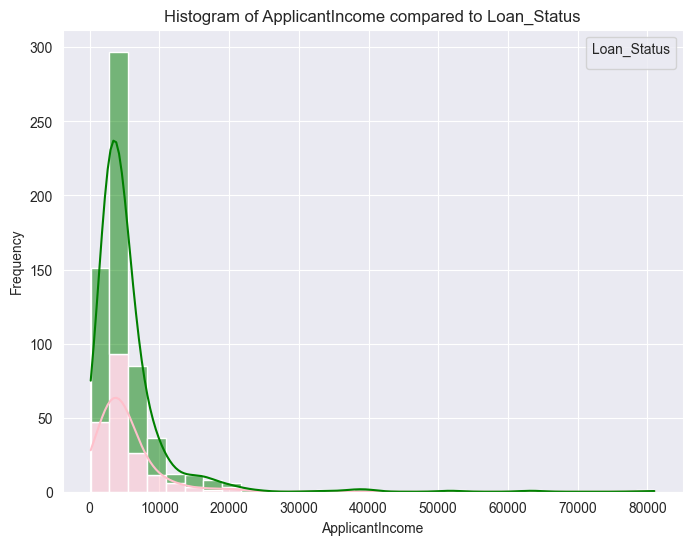

/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_

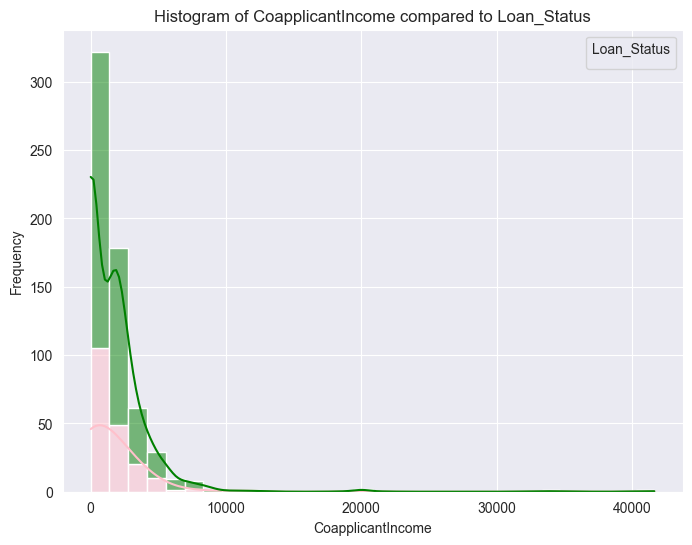

/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_

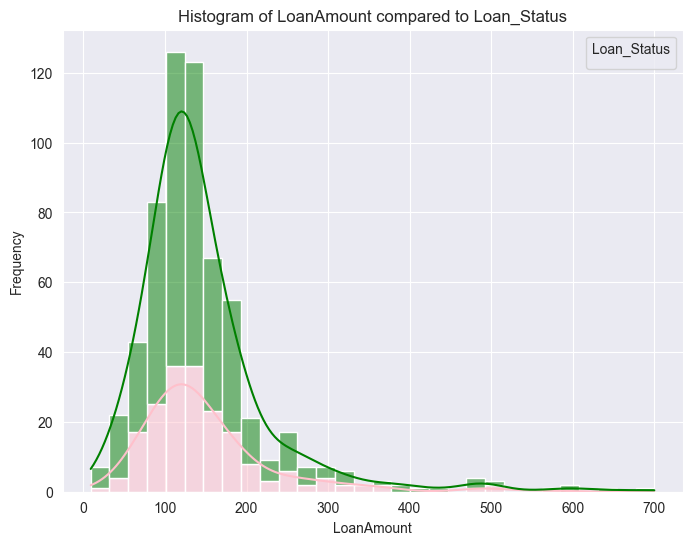

/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_

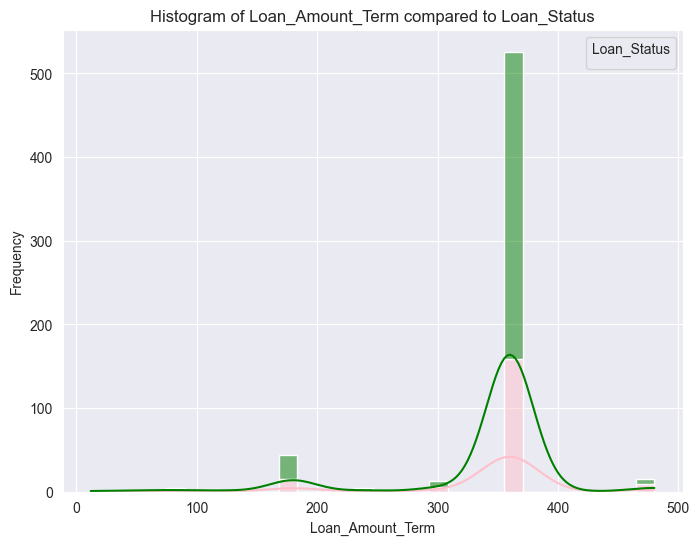

/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_

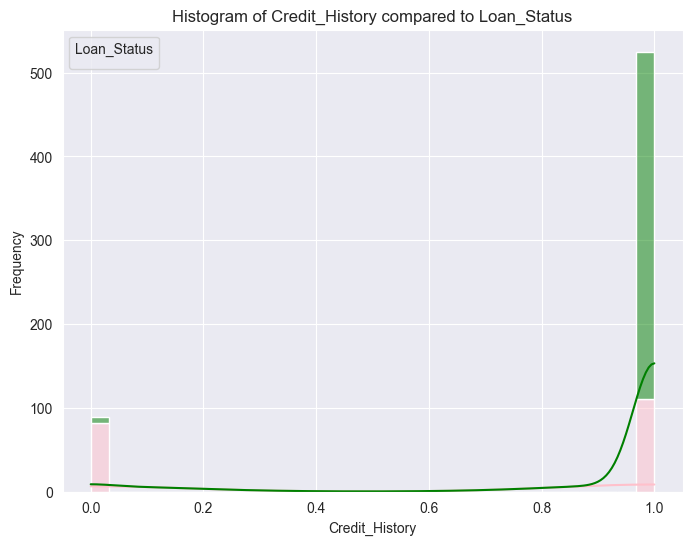

In [18]:
custom_palette = {'Y': 'green', 'N': 'pink'}
for col in num.columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=data, x=col, hue='Loan_Status', multiple="stack", kde=True, palette=custom_palette, bins=30)
    plt.title(f"Histogram of {col} compared to Loan_Status")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend(title='Loan_Status')
    plt.show()

/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/kshitijsinghrawat/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

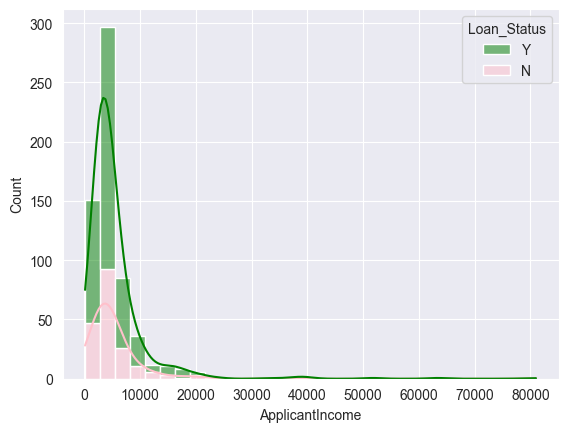

In [19]:
sns.histplot(data=data, x= 'ApplicantIncome' , hue='Loan_Status', multiple="stack", kde=True, palette=custom_palette, bins=30)

In [20]:
num

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849,0.0,128.0,360.0,1.0
1,4583,1508.0,128.0,360.0,1.0
2,3000,0.0,66.0,360.0,1.0
3,2583,2358.0,120.0,360.0,1.0
4,6000,0.0,141.0,360.0,1.0
...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0
610,4106,0.0,40.0,180.0,1.0
611,8072,240.0,253.0,360.0,1.0
612,7583,0.0,187.0,360.0,1.0


<Axes: xlabel='ApplicantIncome', ylabel='LoanAmount'>

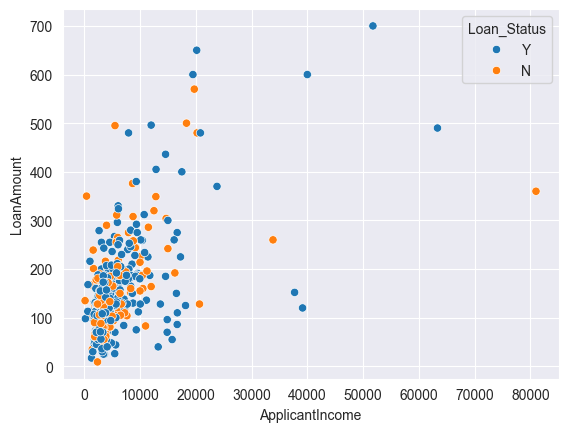

In [21]:
sns.scatterplot(data = data , x = 'ApplicantIncome' , y = 'LoanAmount' , hue='Loan_Status')

In [22]:
from sklearn.preprocessing import LabelEncoder

non_num = data.select_dtypes(exclude=['float64', 'int64']).columns
label_encoder = LabelEncoder()
for col in non_num :
    data[col] = label_encoder.fit_transform(data[col])
print(data.head())

   Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0        0       1        0           0          0              0   
1        1       1        1           1          0              0   
2        2       1        1           0          0              1   
3        3       1        1           0          1              0   
4        4       1        0           0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Property_Area  Loan_Status  
0             1.0              2            1  
1             1.0              0            0  
2             

In [23]:
from sklearn.preprocessing import LabelEncoder

non_num = data.select_dtypes(exclude=['float64', 'int64']).columns
label_encoder = LabelEncoder()
for col in non_num :
    data[col] = label_encoder.fit_transform(data[col])
print(data.head())

   Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0        0       1        0           0          0              0   
1        1       1        1           1          0              0   
2        2       1        1           0          0              1   
3        3       1        1           0          1              0   
4        4       1        0           0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Property_Area  Loan_Status  
0             1.0              2            1  
1             1.0              0            0  
2             

In [24]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
